# NeuroScroll

# What we gonna do in this project ? 

`Summary:-`

`We gonna create the load the dataset `

# Import libraries

In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly as pl
import regex

# Load the dataset

In [32]:
data_load = pd.read_csv('/Users/shyamalkar/Desktop/DS_project/Dataset_only/social_media_dopamine_productivity.csv')
df = data_load


In [33]:
df.head()

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
0,P0001,synthetic_ai,1,16,13-17,Female,South Asian,Indian,India,High school,...,Yes,9,2,3,Boredom,Critical,8.8,9.2,2.1,9.5
1,P0002,synthetic_ai,1,17,13-17,Male,East Asian,Chinese,China,High school,...,Yes,10,1,1,Curiosity,Critical,9.5,9.8,1.5,9.8
2,P0003,synthetic_ai,1,15,13-17,Female,Black/African,Nigerian,Nigeria,High school,...,Yes,8,2,5,Boredom,Severe,8.0,8.5,2.8,9.0
3,P0004,synthetic_ai,1,19,18-22,Male,White/Caucasian,American,USA,High school,...,Yes,9,3,7,Boredom,Severe,7.8,8.2,2.9,8.8
4,P0005,synthetic_ai,1,18,18-22,Female,Hispanic/Latino,Mexican,Mexico,High school,...,Yes,9,2,4,FOMO,Critical,9.0,9.3,2.0,9.6


`See full column values `

In [34]:
# Shows column names vertically, with the first 5 rows of data next to them
df.info(max_cols=66)


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    300 non-null    str    
 1   data_source                       300 non-null    str    
 2   synthetic_flag                    300 non-null    int64  
 3   age                               300 non-null    int64  
 4   age_group                         300 non-null    str    
 5   gender                            300 non-null    str    
 6   race_ethnicity                    300 non-null    str    
 7   nationality                       300 non-null    str    
 8   country_of_residence              300 non-null    str    
 9   education_level                   300 non-null    str    
 10  employment_status                 300 non-null    str    
 11  occupation_category               300 non-null    str    
 12  relationship_status

In [35]:
col = df['age_group'].isnull().sum()

print(col)


0


In [36]:
# Scan text columns for hidden missing value strings
text_cols = df.select_dtypes(include=['object', 'string']).columns

print("--- Hidden Missing Value Check ---")
for col in text_cols:
    # Get the top 5 most frequent values in that column
    top_values = df[col].value_counts().head(5).index.tolist()
    print(f"Column '{col}' top values: {top_values}")


--- Hidden Missing Value Check ---
Column 'participant_id' top values: ['P0001', 'P0002', 'P0003', 'P0004', 'P0005']
Column 'data_source' top values: ['synthetic_ai']
Column 'age_group' top values: ['36-49', '28-35', '18-22', '23-27', '50-59']
Column 'gender' top values: ['Female', 'Male', 'Non-binary']
Column 'race_ethnicity' top values: ['White/Caucasian', 'East Asian', 'Black/African', 'South Asian', 'Hispanic/Latino']
Column 'nationality' top values: ['Indian', 'American', 'Nigerian', 'Chinese', 'Mexican']
Column 'country_of_residence' top values: ['India', 'USA', 'Nigeria', 'China', 'Mexico']
Column 'education_level' top values: ['Undergraduate', 'Postgraduate', 'High school']
Column 'employment_status' top values: ['Full-time employed', 'Student', 'Retired', 'Part-time employed', 'Job seeker']
Column 'occupation_category' top values: ['Education', 'Technology', 'Other', 'Healthcare', 'Finance']
Column 'relationship_status' top values: ['Married', 'Single', 'In a relationship', 'D

In [37]:
print(df.dtypes)


participant_id                      str
data_source                         str
synthetic_flag                    int64
age                               int64
age_group                           str
                                 ...   
productivity_decline_score          str
dopamine_dysregulation_index    float64
digital_wellbeing_score         float64
sm_addiction_risk_score         float64
notes                           float64
Length: 66, dtype: object


`Check - How many unique nationality has in this dataset`

In [38]:
col = df['nationality'].unique()

print(len(col))


39


In [39]:
print(len(df.columns))

66


In [40]:
df.tail()

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
295,P0296,synthetic_ai,1,24,23-27,Female,White/Caucasian,British,UK,Undergraduate,...,Yes,9,3,6,Comparison,Severe,7.8,8.2,2.9,8.7
296,P0297,synthetic_ai,1,35,28-35,Male,Black/African,Senegalese,Senegal,Undergraduate,...,Sometimes,4,5,18,FOMO,Early,4.8,5.4,5.4,5.8
297,P0298,synthetic_ai,1,20,18-22,Female,Hispanic/Latino,Mexican,Mexico,High school,...,Yes,9,2,3,FOMO,Critical,9.2,9.5,2.0,9.7
298,P0299,synthetic_ai,1,46,36-49,Male,East Asian,Filipino,Philippines,Undergraduate,...,Rarely,3,6,28,Boredom,None/Minimal,3.2,3.8,7.0,4.0
299,P0300,synthetic_ai,1,22,18-22,Male,Black/African,Nigerian,Nigeria,Undergraduate,...,Yes,9,2,3,Boredom,Critical,9.0,9.4,2.1,9.6


In [41]:
df.isnull().sum() # here we can see age group has - 27 missing value


participant_id                  0
data_source                     0
synthetic_flag                  0
age                             0
age_group                       0
                               ..
productivity_decline_score      0
dopamine_dysregulation_index    0
digital_wellbeing_score         0
sm_addiction_risk_score         0
notes                           0
Length: 66, dtype: int64

In [42]:
high_age = df['age_group'].max()
print(high_age)


60+


In [43]:
unique  = df['country_of_residence'].unique()
print(len(unique))

39


In [44]:
df.describe() 

,synthetic_flag,age,avg_daily_sm_hours,years_on_social_media,avg_daily_screen_time_hours,avg_sleep_hours,avg_work_study_hours_per_day,dopamine_rush_feel_score,reward_seeking_behavior,fomo_score,...,decision_fatigue_score,anxiety_when_phone_unavailable,restlessness_score,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
count,300.0,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1.0,36.310000,4.030000,7.503333,7.830000,7.325000,7.100000,4.920000,2.556667,4.590000,...,3.963333,4.300000,4.143333,4.283333,5.413333,28.740000,4.354333,4.853667,6.170333,5.006000
std,0.0,15.175029,2.034181,2.690872,2.271556,1.033005,2.673417,2.490168,1.308624,2.142553,...,2.414142,2.792129,2.610012,2.925449,2.575123,23.587999,2.750095,2.692319,2.649709,2.922093
min,1.0,15.000000,0.500000,3.000000,3.000000,4.500000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.500000,1.000000,1.100000,0.500000
25%,1.0,24.000000,2.500000,5.000000,6.375000,6.875000,6.000000,3.000000,1.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,10.000000,1.800000,2.400000,4.200000,2.200000
50%,1.0,33.500000,3.500000,8.000000,7.500000,7.500000,8.000000,4.000000,2.000000,4.000000,...,3.000000,3.000000,3.500000,3.000000,6.000000,24.000000,3.200000,3.800000,7.000000,4.000000
75%,1.0,46.250000,5.500000,10.000000,9.500000,8.000000,9.000000,7.000000,3.000000,6.000000,...,5.000000,7.000000,6.000000,7.000000,8.000000,48.000000,6.200000,6.800000,8.800000,7.200000
max,1.0,75.000000,9.000000,14.000000,13.000000,9.000000,9.500000,10.000000,5.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,90.000000,9.900000,10.000000,9.900000,10.000000


In [45]:
df.tail() #last 5 rows

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
295,P0296,synthetic_ai,1,24,23-27,Female,White/Caucasian,British,UK,Undergraduate,...,Yes,9,3,6,Comparison,Severe,7.8,8.2,2.9,8.7
296,P0297,synthetic_ai,1,35,28-35,Male,Black/African,Senegalese,Senegal,Undergraduate,...,Sometimes,4,5,18,FOMO,Early,4.8,5.4,5.4,5.8
297,P0298,synthetic_ai,1,20,18-22,Female,Hispanic/Latino,Mexican,Mexico,High school,...,Yes,9,2,3,FOMO,Critical,9.2,9.5,2.0,9.7
298,P0299,synthetic_ai,1,46,36-49,Male,East Asian,Filipino,Philippines,Undergraduate,...,Rarely,3,6,28,Boredom,None/Minimal,3.2,3.8,7.0,4.0
299,P0300,synthetic_ai,1,22,18-22,Male,Black/African,Nigerian,Nigeria,Undergraduate,...,Yes,9,2,3,Boredom,Critical,9.0,9.4,2.1,9.6


In [46]:
df.info(verbose=True, show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    300 non-null    str    
 1   data_source                       300 non-null    str    
 2   synthetic_flag                    300 non-null    int64  
 3   age                               300 non-null    int64  
 4   age_group                         300 non-null    str    
 5   gender                            300 non-null    str    
 6   race_ethnicity                    300 non-null    str    
 7   nationality                       300 non-null    str    
 8   country_of_residence              300 non-null    str    
 9   education_level                   300 non-null    str    
 10  employment_status                 300 non-null    str    
 11  occupation_category               300 non-null    str    
 12  relationship_status

In [47]:
df.isnull().sum()

participant_id                  0
data_source                     0
synthetic_flag                  0
age                             0
age_group                       0
                               ..
productivity_decline_score      0
dopamine_dysregulation_index    0
digital_wellbeing_score         0
sm_addiction_risk_score         0
notes                           0
Length: 66, dtype: int64

`In this dataset age group has value 34-45 etc... we gonna average the column value. `

`for better understanding the machine learnign model and also for division`

In [48]:
col = df['age_group']
#print(col.max)
print(col.min())
print(col.max())


13-17
60+


`Here we gonna set a regex pattern `

`why ? `

Because in this dataset there are wrong format values like = -, +, /  etc.... 

So i gonna set the pattern where remove the unnecessary syntax and make it suitable
 format and last coding where we put the age_group column and 
apply the division pattern and these number first calculate the
 sum and then divide . and convert into float value number. 

In [49]:


# 2. Define the regex pattern with capture groups
pattern = r'(\d+)[-+/](\d+)'

# 3. Extract the two numbers into temporary columns
extracted = df['age_group'].str.extract(pattern).astype(float)

# 4. Calculate the average of the two columns
df['age_group'] = (extracted[0] + extracted[1]) / 2

print(df)


    participant_id   data_source  synthetic_flag  age  age_group  gender  \
0            P0001  synthetic_ai               1   16       15.0  Female   
1            P0002  synthetic_ai               1   17       15.0    Male   
2            P0003  synthetic_ai               1   15       15.0  Female   
3            P0004  synthetic_ai               1   19       20.0    Male   
4            P0005  synthetic_ai               1   18       20.0  Female   
..             ...           ...             ...  ...        ...     ...   
295          P0296  synthetic_ai               1   24       25.0  Female   
296          P0297  synthetic_ai               1   35       31.5    Male   
297          P0298  synthetic_ai               1   20       20.0  Female   
298          P0299  synthetic_ai               1   46       42.5    Male   
299          P0300  synthetic_ai               1   22       20.0    Male   

      race_ethnicity nationality country_of_residence education_level  ...  \
0        

In [50]:
df.columns

Index(['participant_id', 'data_source', 'synthetic_flag', 'age', 'age_group',
       'gender', 'race_ethnicity', 'nationality', 'country_of_residence',
       'education_level', 'employment_status', 'occupation_category',
       'relationship_status', 'avg_daily_sm_hours', 'years_on_social_media',
       'primary_platform', 'secondary_platform', 'daily_check_frequency',
       'first_check_of_day', 'late_night_scrolling', 'sm_during_work_study',
       'sm_during_meals', 'notifications_always_on', 'scroll_without_purpose',
       'doomscrolling_frequency', 'content_type_consumed',
       'avg_daily_screen_time_hours', 'avg_sleep_hours', 'sleep_quality',
       'exercise_frequency', 'avg_work_study_hours_per_day',
       'dopamine_rush_feel_score', 'reward_seeking_behavior', 'fomo_score',
       'comparison_to_others_score', 'validation_seeking_score',
       'boredom_to_phone_reflex', 'inability_to_delay_gratification',
       'attention_span_minutes', 'deep_work_duration_minutes',
   

In [51]:
col = df['age_group']
#print(col.max)
print(col.min())
print(col.max())


15.0
54.5


# Visualization

`Here i gonna visualize the most important visualization`

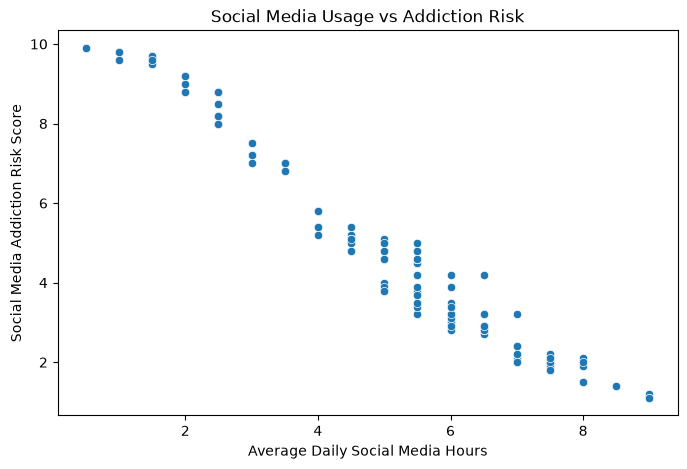

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_daily_sm_hours",
    y="sm_addiction_risk_score"
)

plt.title("Social Media Usage vs Addiction Risk")
plt.xlabel("Average Daily Social Media Hours")
plt.ylabel("Social Media Addiction Risk Score")
plt.show()

# Screen time or Sleep 


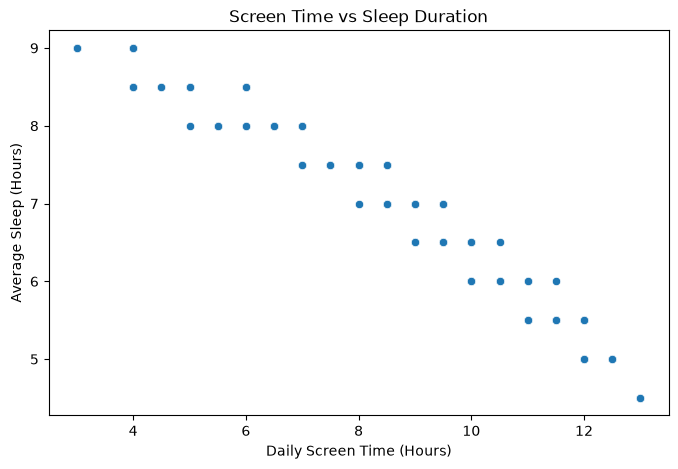

In [53]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_daily_screen_time_hours",
    y="avg_sleep_hours"
)

plt.title("Screen Time vs Sleep Duration")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Average Sleep (Hours)")
plt.show()

# Social media usage or productivity 

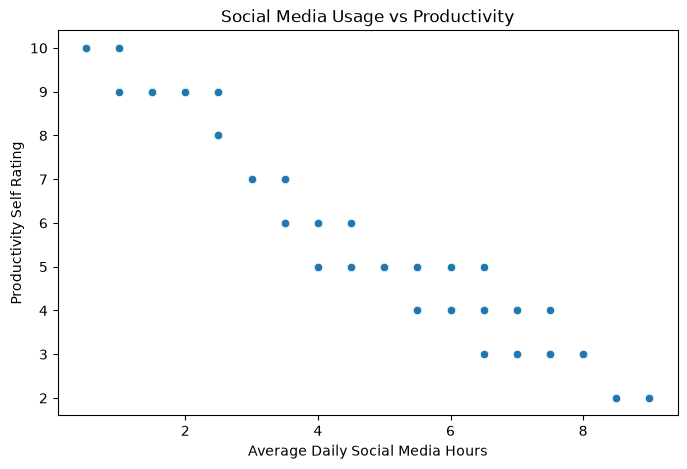

In [54]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_daily_sm_hours",
    y="productivity_self_rating"
)

plt.title("Social Media Usage vs Productivity")
plt.xlabel("Average Daily Social Media Hours")
plt.ylabel("Productivity Self Rating")
plt.show()

# Employment status vs Social media usage 

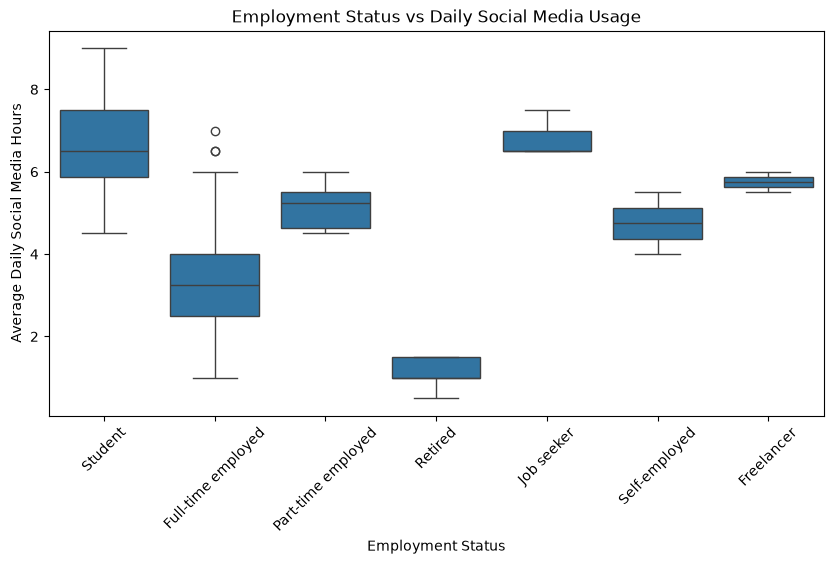

In [55]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="employment_status",
    y="avg_daily_sm_hours"
)

plt.title("Employment Status vs Daily Social Media Usage")
plt.xlabel("Employment Status")
plt.ylabel("Average Daily Social Media Hours")

plt.xticks(rotation=45)

plt.show()

# Correlation heatmap

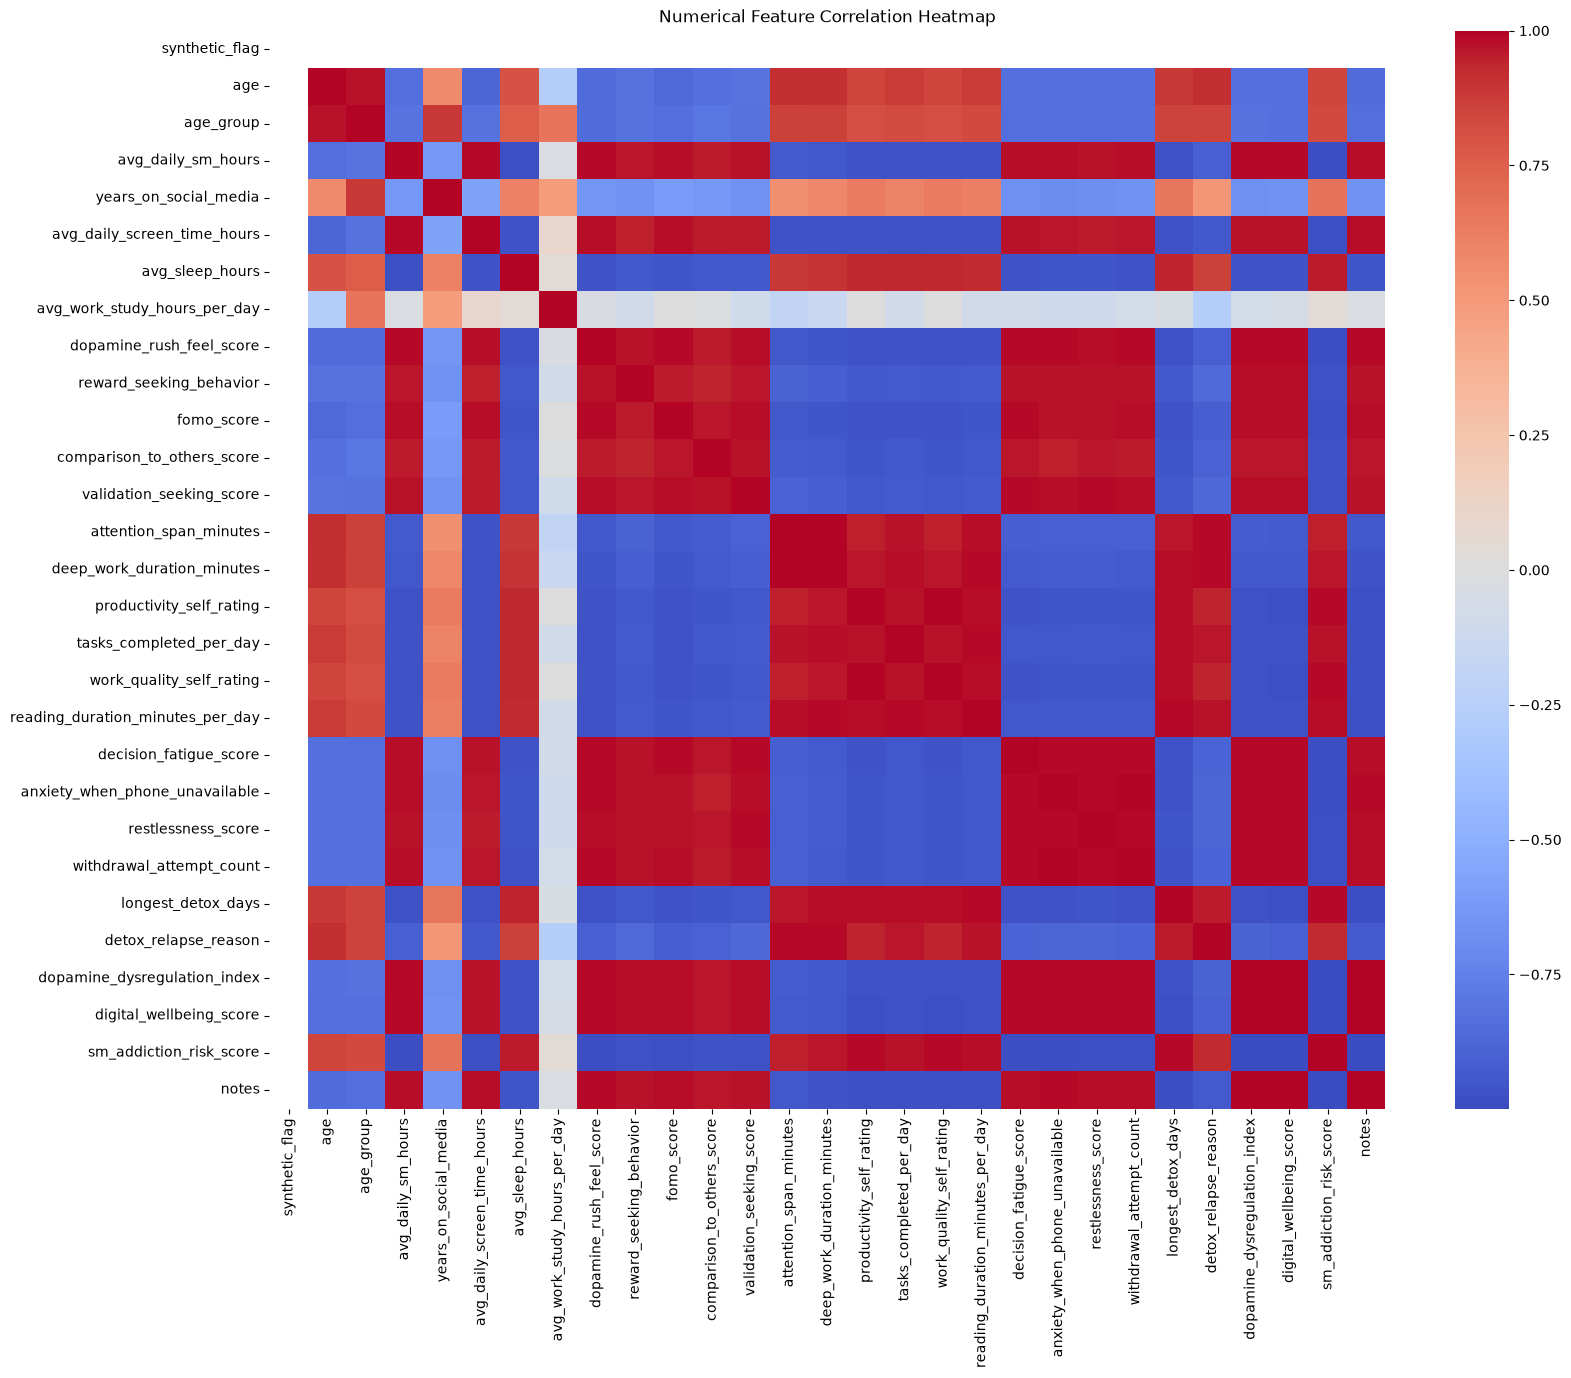

In [56]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(18, 14))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation Heatmap")
plt.show()

# Attention vs Deep work 

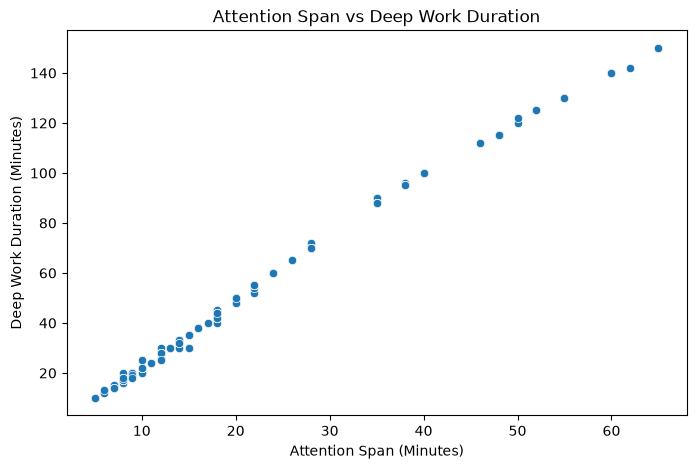

In [57]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attention_span_minutes",
    y="deep_work_duration_minutes"
)

plt.title("Attention Span vs Deep Work Duration")
plt.xlabel("Attention Span (Minutes)")
plt.ylabel("Deep Work Duration (Minutes)")

plt.show()

# Difficulty maintaining vs Work Quality 

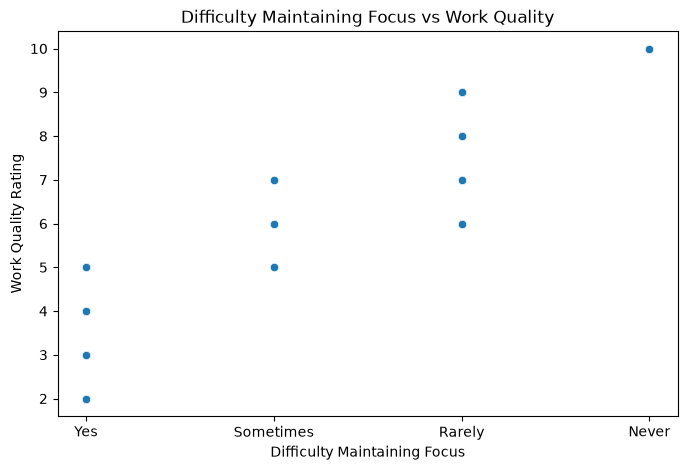

In [58]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="difficulty_maintaining_focus",
    y="work_quality_self_rating"
)

plt.title("Difficulty Maintaining Focus vs Work Quality")
plt.xlabel("Difficulty Maintaining Focus")
plt.ylabel("Work Quality Rating")

plt.show()